30.122500000000002 29.835625 29.835625 10.20625


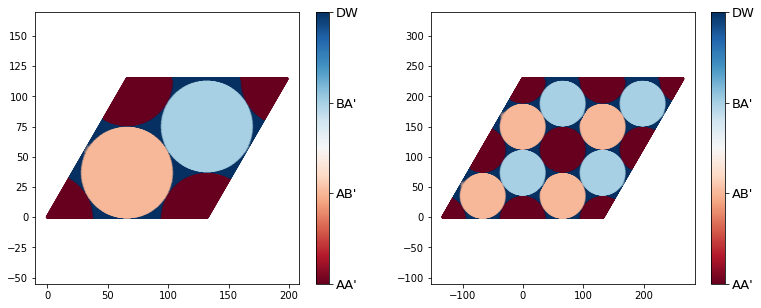

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.interpolate import griddata
#step1 load data
tb_ri=np.genfromtxt("tB_ri")
bb_ri=np.genfromtxt("bB_ri")
tn_ri=np.genfromtxt("tN_ri")
bn_ri=np.genfromtxt("bN_ri")

# tb_re=np.genfromtxt("tB_re")
# bb_re=np.genfromtxt("bB_re")
# tn_re=np.genfromtxt("tN_re")
# bn_re=np.genfromtxt("bN_re")

tB_x = np.loadtxt('tb_ri',usecols=(0,))
tB_y = np.loadtxt('tb_ri',usecols=(1,))
tB_z = np.loadtxt('tb_ri',usecols=(2,))
tN_x = np.loadtxt('tn_ri',usecols=(0,))
tN_y = np.loadtxt('tn_ri',usecols=(1,))
tN_z = np.loadtxt('tn_ri',usecols=(2,))
bB_x = np.loadtxt('bb_ri',usecols=(0,))
bB_y = np.loadtxt('bb_ri',usecols=(1,))
bB_z = np.loadtxt('bb_ri',usecols=(2,))
bN_x = np.loadtxt('bn_ri',usecols=(0,))
bN_y = np.loadtxt('bn_ri',usecols=(1,))
bN_z = np.loadtxt('bn_ri',usecols=(2,))

# tB_x = np.loadtxt('tb_re',usecols=(0,))
# tB_y = np.loadtxt('tb_re',usecols=(1,))
# tB_z = np.loadtxt('tb_re',usecols=(2,))
# tN_x = np.loadtxt('tn_re',usecols=(0,))
# tN_y = np.loadtxt('tn_re',usecols=(1,))
# tN_z = np.loadtxt('tn_re',usecols=(2,))
# bB_x = np.loadtxt('bb_re',usecols=(0,))
# bB_y = np.loadtxt('bb_re',usecols=(1,))
# bB_z = np.loadtxt('bb_re',usecols=(2,))
# bN_x = np.loadtxt('bn_re',usecols=(0,))
# bN_y = np.loadtxt('bn_re',usecols=(1,))
# bN_z = np.loadtxt('bn_re',usecols=(1,))
a=132.33893899756035
T = a*np.array([[1,0],[0.5,np.sqrt(3)/2]])
tB_x = np.append(tB_x,tB_x-1*T[0,0])
tB_y = np.append(tB_y,tB_y-1*T[0,1])
tB_x = np.append(tB_x,tB_x-1*T[1,0])
tB_y = np.append(tB_y,tB_y-1*T[1,1])
tB_x = np.append(tB_x,tB_x+1*T[0,0])
tB_y = np.append(tB_y,tB_y+1*T[0,1])
tB_x = np.append(tB_x,tB_x+1*T[1,0])
tB_y = np.append(tB_y,tB_y+1*T[1,1])

tN_x = np.append(tN_x,tN_x-1*T[0,0])
tN_y = np.append(tN_y,tN_y-1*T[0,1])
tN_x = np.append(tN_x,tN_x-1*T[1,0])
tN_y = np.append(tN_y,tN_y-1*T[1,1])
tN_x = np.append(tN_x,tN_x+1*T[0,0])
tN_y = np.append(tN_y,tN_y+1*T[0,1])
tN_x = np.append(tN_x,tN_x+1*T[1,0])
tN_y = np.append(tN_y,tN_y+1*T[1,1])

bN_x = np.append(bN_x,bN_x-1*T[0,0])
bN_y = np.append(bN_y,bN_y-1*T[0,1])
bN_x = np.append(bN_x,bN_x-1*T[1,0])
bN_y = np.append(bN_y,bN_y-1*T[1,1])
bN_x = np.append(bN_x,bN_x+1*T[0,0])
bN_y = np.append(bN_y,bN_y+1*T[0,1])
bN_x = np.append(bN_x,bN_x+1*T[1,0])
bN_y = np.append(bN_y,bN_y+1*T[1,1])

bB_x = np.append(bB_x,bB_x-1*T[0,0])
bB_y = np.append(bB_y,bB_y-1*T[0,1])
bB_x = np.append(bB_x,bB_x-1*T[1,0])
bB_y = np.append(bB_y,bB_y-1*T[1,1])
bB_x = np.append(bB_x,bB_x+1*T[0,0])
bB_y = np.append(bB_y,bB_y+1*T[0,1])
bB_x = np.append(bB_x,bB_x+1*T[1,0])
bB_y = np.append(bB_y,bB_y+1*T[1,1])

del_r_bb = []
del_r_bn = []
del_r_nb = []
del_r_nn = []

for elx, ely in zip(bB_x,bB_y):
    dx = tB_x-elx
    dy = tB_y-ely
    dr_BB = np.sqrt(dx**2 + dy**2).min()
    del_r_bb.append(dr_BB)
for elx, ely in zip(bN_x,bN_y):
    dx = tB_x-elx
    dy = tB_y-ely
    dr_BN = np.sqrt(dx**2 + dy**2).min()
    del_r_bn.append(dr_BN)
for elx, ely in zip(bB_x,bB_y):
    dx = tN_x-elx
    dy = tN_y-ely
    dr_NB = np.sqrt(dx**2 + dy**2).min()
    del_r_nb.append(dr_NB)
for elx, ely in zip(bN_x,bN_y):
    dx = tN_x-elx
    dy = tN_y-ely
    dr_NN = np.sqrt(dx**2 + dy**2).min()
    del_r_nn.append(dr_NN)   
del_r_bb=np.array(del_r_bb)
del_r_bn=np.array(del_r_bn)
del_r_nb=np.array(del_r_nb)
del_r_nn=np.array(del_r_nn)
num = 400
a1 = np.linspace(0,1,num)
a2 = np.linspace(0,1,num)
a1,a2=np.meshgrid(a1,a2)
XY=np.outer(a1.flatten(),T[0])+np.outer(a2.flatten(),T[1])
X=XY[:,0]
Y=XY[:,1]

from scipy.interpolate import griddata
bb_intep=griddata((bB_x,bB_y),del_r_bb,(X, Y), method='cubic')
bn_intep=griddata((bN_x,bN_y),del_r_bn,(X, Y), method='cubic')
nb_intep=griddata((bB_x,bB_y),del_r_nb,(X, Y), method='cubic')
nn_intep=griddata((bN_x,bN_y),del_r_nn,(X, Y), method='cubic')

cond = np.logical_not(np.isnan(bb_intep) | np.isnan(nb_intep) |np.isnan(bn_intep))
X = X[cond]
Y = Y[cond]
bb_intep = bb_intep[cond]
bn_intep = bn_intep[cond]
nb_intep = nb_intep[cond]
bd=[]
ratio=7.2/10
bond=2.505/np.sqrt(3)
ss=X.shape[0]
eps=0.1
for i in range(ss):
    if bn_intep[i]< ratio and bb_intep[i] > ratio:
        bd.append(0) #AA' stacking
    elif nn_intep[i]< ratio:
        bd.append(1) #AB stacking
    elif bb_intep[i]< ratio:
        bd.append(2) #AB stacking
    elif (bb_intep[i] == np.nan): # or (bn_intep[i]==None) or (nb_intep[i]==None):
        bd.append(None)
    else:
        bd.append(3)
bd = np.asarray(bd)
plt.figure(figsize=(13,5))
plt.subplot(121)
plt.scatter(X,Y,c=bd,s=10,cmap='RdBu',edgecolor='none')
plt.axis('equal')
cbar = plt.colorbar()
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(["AA'", "AB'", "BA'","DW"],fontsize=13)   
plt.subplot(122)
plt.scatter(X,Y,c=bd,s=10,cmap='RdBu',edgecolor='none')
plt.scatter(X-T[0,0],Y-T[0,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
plt.scatter(X+T[1,0],Y+T[1,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
plt.scatter(X-T[0,0]+T[1,0],Y-T[0,1]+T[1,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
# plt.scatter(X+T[0,0],Y+T[0,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
# plt.scatter(X-T[1,0],Y-T[1,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
# plt.scatter(X-T[0,0]-T[1,0],Y-T[0,1]-T[1,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
# plt.scatter(X+T[0,0]+T[1,0],Y+T[0,1]+T[1,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
# plt.scatter(X+T[0,0]-T[1,0],Y+T[0,1]-T[1,1],c=bd,s=10,cmap='RdBu',edgecolor='none')
plt.axis('equal')
cbar = plt.colorbar()
cbar.set_ticks([0, 1, 2, 3])
cbar.set_ticklabels(["AA'", "AB'", "BA'","DW"],fontsize=13)     
AA=(bd[bd==0].size/bd.size)*100
AB=(bd[bd==1].size/bd.size)*100
BA=(bd[bd==2].size/bd.size)*100
DW=(bd[bd==3].size/bd.size)*100

print(AA,AB,BA,DW)
